# An electric car or a petrol one

A household is replacing its car and keeping the next one for eight years,
driving about 15,000 km a year. The battery car lists at 42,000 and needs a
wallbox; the petrol car lists at 33,500. The battery car also attracts three
public benefits, and the petrol car burns a fuel whose price nobody can
promise.

Every number below comes out of `simplyinvest.car`, which supplies the
distance quantity `"km"`, the carriers that price it, and the German
incentives. The appraisal engine underneath knows none of that.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter

from simplyinvest import GeometricDecline, Term, Timeline
from simplyinvest.appraisal import Alternative, Case
from simplyinvest.car import (
    CarOperating,
    Electricity,
    Household,
    Mileage,
    Petrol,
    Propulsion,
    Vehicle,
)
from simplyinvest.car.incentives import CirculationTaxExemption, GhgQuota, PurchasePremium
from simplyinvest.financing import CashPurchase
from simplyinvest.report import (
    breakdown_chart,
    breakdown_frame,
    cumulative_chart,
    differential_chart,
    money_formatter,
    ranking_frame,
    sweep_chart,
    tornado_chart,
    tornado_frame,
)
from simplyinvest.uncertain import (
    LogNormal,
    Normal,
    one_way,
    simulate,
    switch_point,
    tornado,
    uncertain,
)

ELECTRIC = "#2b6cb0"
PETROL = "#c05621"

# Every chart in simplyinvest.report takes its colours from the active cycle,
# so the whole notebook is styled once, here.
plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.prop_cycle": plt.cycler(color=[ELECTRIC, PETROL]),
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

MONEY = money_formatter()

## The two cars

A `Vehicle` is the domain's `Asset`: a price, a residual curve, an energy
source and the fixed annual costs of keeping it on the road. The electric
car's consumption is quoted at the battery, so the 10% charging loss is
billed on top — the meter sees more energy than the battery stores.

In [2]:
electric = Vehicle(
    name="Electric",
    price=42_000.0,
    propulsion=Propulsion.BEV,
    energy=Electricity(
        consumption=17.5,      # kWh per 100 km, at the battery
        price=0.31,            # home tariff
        public_price=0.55,
        home_share=0.8,
        charging_loss=0.10,    # billed at the meter, not at the battery
    ),
    residual=GeometricDecline(0.15),
    insurance=780.0,
    maintenance=350.0,
    circulation_tax=180.0,
    infrastructure_cost=1_400.0,   # the wallbox
    first_registration=date(2026, 4, 1),
)

petrol = Vehicle(
    name="Petrol",
    price=33_500.0,
    propulsion=Propulsion.ICE,
    energy=Petrol(consumption=6.4, price=1.79, real_world_factor=1.15),
    residual=GeometricDecline(0.13),
    insurance=640.0,
    maintenance=620.0,
    circulation_tax=190.0,
)

timeline = Timeline(
    Term.of_years(8),
    periods_per_year=12,
    rate=0.03,
    start_date=date(2026, 4, 1),
    escalations={"energy": 0.03, "running_cost": 0.02},
)
buyer = Household(taxable_income=52_000.0, children=1)
usage = Mileage(annual_km=15_000.0)

display(
    pd.DataFrame(
        {
            car.name: {
                "list price": float(car.price),
                "wallbox": float(car.infrastructure_cost),
                "insurance a year": float(car.insurance),
                "maintenance a year": float(car.maintenance),
                "circulation tax a year": float(car.circulation_tax),
                "energy per km at t=1": float(car.energy.cost_per_km(timeline)[1]),
            }
            for car in (electric, petrol)
        }
    )
)

,Electric,Petrol
list price,"42,000.00","33,500.00"
wallbox,"1,400.00",0.00
insurance a year,780.00,640.00
maintenance a year,350.00,620.00
circulation tax a year,180.00,190.00
energy per km at t=1,0.07,0.13


## The verdict

Each alternative is a name and some flow sources. The electric car carries
three more: the means-tested purchase premium, the annual greenhouse-gas
quota credit, and the circulation-tax exemption.

In [3]:
electric_plan = Alternative(
    "Electric",
    sources=(
        CashPurchase().bind(electric),
        CarOperating(electric),
        PurchasePremium().bind(electric),
        GhgQuota(annual_amount=300.0).bind(electric),
        CirculationTaxExemption().bind(electric),
    ),
)
petrol_plan = Alternative(
    "Petrol",
    sources=(CashPurchase().bind(petrol), CarOperating(petrol)),
)

case = Case(
    alternatives=(electric_plan, petrol_plan),
    timeline=timeline,
    party=buyer,
    usage=usage,
)
result = case.run()

ranked = ranking_frame(result)
ranked["cost per km"] = [result[name].cost_per_unit("km") for name in ranked.index]
display(ranked[["npv", "eac", "cost per km"]])

print(result.verdict())

,npv,eac,cost per km
alternative,,,
Electric,"-44,645.18","8,356.34",0.56
Petrol,"-51,453.16","8,527.23",0.57


Electric is better than Petrol by 6,807.98 in present value.


## Where the money goes

The breakdown sums to the net present value by construction, so nothing can
hide between the parts and the total. Each source labels its own flows, which
is why the three benefits appear as three separate lines rather than as a
discount on the price.

,Electric,Petrol
component,,
capital/purchase,"-42,000.00","-33,500.00"
capital/setup,"-1,400.00",0.00
incentive/ghg_quota,"2,105.91",0.00
incentive/purchase_premium,"4,455.88",0.00
incentive/tax_exemption,"1,369.95",0.00
operating/circulation_tax,"-1,369.95","-1,446.05"
operating/energy,"-8,241.23","-15,597.11"
operating/insurance,"-5,936.43","-4,870.92"
operating/maintenance,"-2,663.78","-4,718.70"


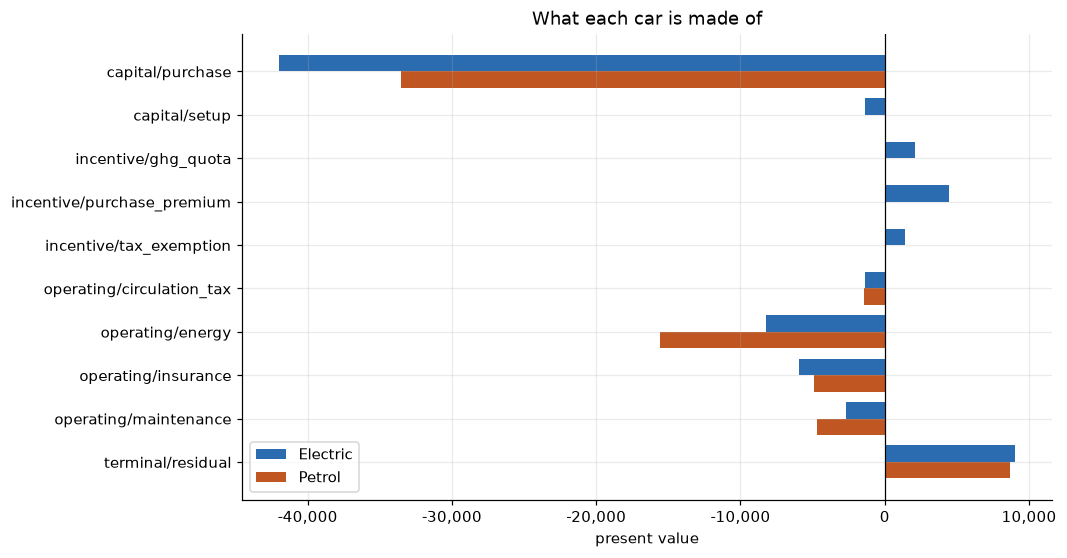

In [4]:
parts = breakdown_frame(result)
display(parts)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
breakdown_chart(result, ax=ax)
ax.set_title("What each car is made of")
ax.legend(loc="lower left")
plt.show()

## What a kilometre costs

Both prices escalate at 3% a year, but they start six cents apart and the
gap widens to eight with them. This is the whole running-cost story in one line each:
everything else about the two cars is within a few hundred a year.

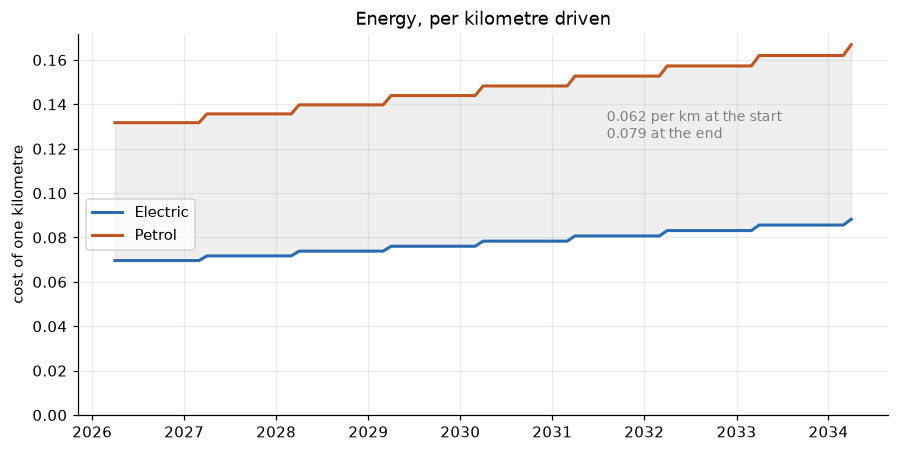

In [5]:
dates = np.array(timeline.dates())
fig, ax = plt.subplots()
for car, colour in zip((electric, petrol), (ELECTRIC, PETROL), strict=True):
    ax.plot(dates, car.energy.cost_per_km(timeline), color=colour, linewidth=2, label=car.name)

ax.fill_between(
    dates,
    electric.energy.cost_per_km(timeline),
    petrol.energy.cost_per_km(timeline),
    color="grey",
    alpha=0.12,
)
gap = petrol.energy.cost_per_km(timeline) - electric.energy.cost_per_km(timeline)
ax.annotate(
    f"{gap[1]:.3f} per km at the start\n{gap[-1]:.3f} at the end",
    xy=(dates[-1], (electric.energy.cost_per_km(timeline)[-1] + petrol.energy.cost_per_km(timeline)[-1]) / 2),
    xytext=(-160, -4),
    textcoords="offset points",
    fontsize=9,
    color="grey",
)
ax.set_ylim(bottom=0.0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.set_ylabel("cost of one kilometre")
ax.set_title("Energy, per kilometre driven")
ax.legend(loc="center left")
plt.show()

## What the state pays towards it

Three benefits, three different shapes. The purchase premium is a single
payment that lands four months after the application. The quota credit is
claimed once a year. The tax exemption is a credit against a cost the car
also carries — so it appears twice in the breakdown above, once as the tax
and once as the credit, netting to nothing while it runs.

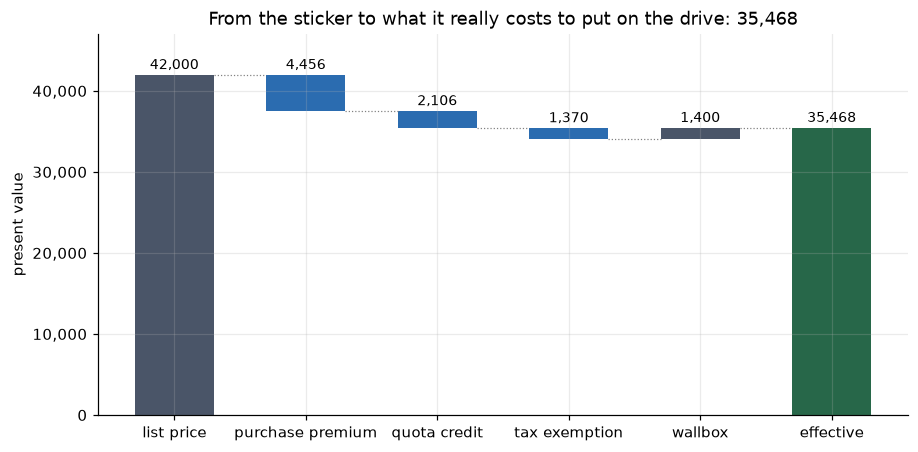

the premium this household qualifies for: 4,500


In [6]:
premium = PurchasePremium()
benefits = {
    "purchase premium": premium.bind(electric),
    "quota credit": GhgQuota(annual_amount=300.0).bind(electric),
    "tax exemption": CirculationTaxExemption().bind(electric),
}
ctx = case.context
values = {name: float(source.flows(ctx).pv(timeline)) for name, source in benefits.items()}

moves = [
    ("list price", float(electric.price)),
    *((name, -value) for name, value in values.items()),
    ("wallbox", float(electric.infrastructure_cost)),
]
heights = np.array([move for _, move in moves])
levels = np.cumsum(heights)             # the running total after each move
starts = np.concatenate([[0.0], levels[:-1]])
labels = [name for name, _ in moves]

fig, ax = plt.subplots()
ax.bar(labels, heights, bottom=starts, color=["#4a5568", ELECTRIC, ELECTRIC, ELECTRIC, "#4a5568"],
       width=0.6)
ax.bar(["effective"], [levels[-1]], color="#276749", width=0.6)

for index in range(len(moves)):
    ax.plot([index + 0.3, index + 0.7], [levels[index]] * 2,
            color="grey", linewidth=0.8, linestyle=":")
for index, (start, height) in enumerate(zip(starts, heights, strict=True)):
    ax.text(index, max(start, start + height) + 700, f"{abs(height):,.0f}",
            ha="center", fontsize=9)
ax.text(len(moves), levels[-1] + 700, f"{levels[-1]:,.0f}", ha="center", fontsize=9)

ax.yaxis.set_major_formatter(MONEY)
ax.set_ylabel("present value")
ax.set_title(f"From the sticker to what it really costs to put on the drive: {levels[-1]:,.0f}")
ax.set_ylim(0, float(electric.price) * 1.12)
plt.show()

print(f"the premium this household qualifies for: {float(premium.grant(buyer)):,.0f}")

## When does it pull ahead?

The electric car costs more on day one and less every kilometre after. The
crossing is the number that actually answers the question, and it is nowhere
near the end of the horizon.

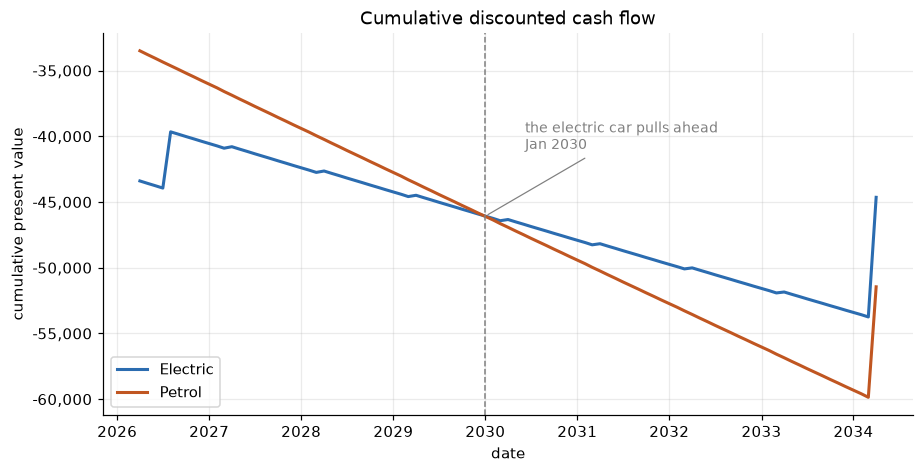

In [7]:
fig, ax = plt.subplots()
cumulative_chart(result, ax=ax)

# The rule is already drawn; this says what it means.
factors = timeline.discount_factors()
cumulative = {name: np.cumsum(result[name].amounts * factors) for name in result.names}
gap = cumulative["Electric"] - cumulative["Petrol"]
crossings = np.flatnonzero(np.sign(gap[:-1]) != np.sign(gap[1:]))
if crossings.size:
    turn = crossings[0] + 1
    ax.annotate(
        f"the electric car pulls ahead\n{dates[turn]:%b %Y}",
        xy=(dates[turn], cumulative["Electric"][turn]),
        xytext=(26, 44),
        textcoords="offset points",
        fontsize=9,
        color="grey",
        arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.8},
    )

ax.set_title("Cumulative discounted cash flow")
ax.legend(loc="lower left")
plt.show()

## What the answer turns on

Marking a number where it is declared makes it addressable. The same price
appears at two addresses once financing is bound to the asset, and both move
together — a sweep cannot leave half the model behind.

The petrol price swings the electric car's value by nothing at all, which is
correct: it is measured on the electric alternative, and no petrol is bought
there.

,low,high,swing
parameter,,,
annual km,"-42,532.87","-46,757.49","4,224.62"
electric price,"-42,561.74","-46,781.42","4,219.68"
power price,"-43,465.12","-45,825.24","2,360.12"
income,"-43,654.99","-45,635.38","1,980.39"
fuel price,"-44,645.18","-44,645.18",0.00


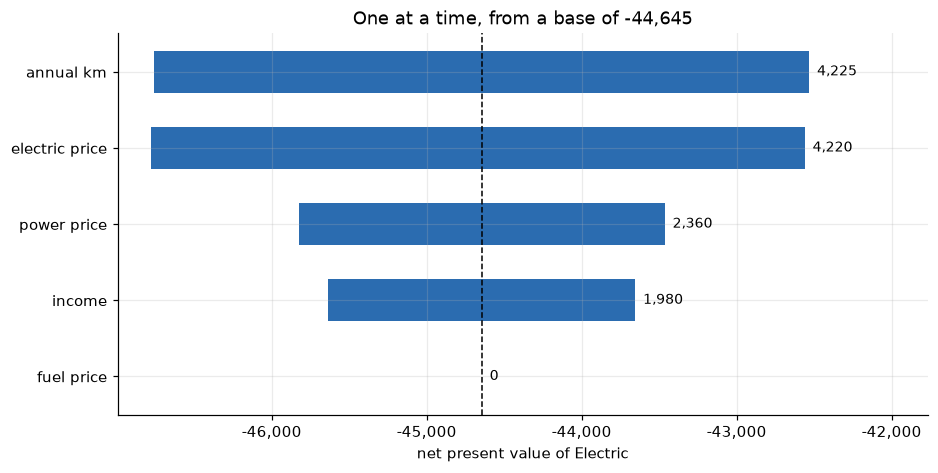

In [8]:
def build(km: float = 15_000.0, income: float = 52_000.0) -> Case:
    car = Vehicle(
        name="Electric",
        price=uncertain(42_000.0, "electric price", LogNormal.from_mean_cv(42_000.0, 0.05)),
        propulsion=Propulsion.BEV,
        energy=Electricity(
            consumption=17.5,
            price=uncertain(0.31, "power price", Normal(0.31, 0.05)),
            public_price=0.55,
            home_share=0.8,
            charging_loss=0.10,
        ),
        residual=GeometricDecline(0.15),
        insurance=780.0,
        maintenance=350.0,
        circulation_tax=180.0,
        infrastructure_cost=1_400.0,
        first_registration=date(2026, 4, 1),
    )
    burner = Vehicle(
        name="Petrol",
        price=33_500.0,
        propulsion=Propulsion.ICE,
        energy=Petrol(
            consumption=6.4,
            price=uncertain(1.79, "fuel price", Normal(1.79, 0.25)),
            real_world_factor=1.15,
        ),
        residual=GeometricDecline(0.13),
        insurance=640.0,
        maintenance=620.0,
        circulation_tax=190.0,
    )
    return Case(
        alternatives=(
            Alternative(
                "Electric",
                (
                    CashPurchase().bind(car),
                    CarOperating(car),
                    PurchasePremium().bind(car),
                    GhgQuota(annual_amount=300.0).bind(car),
                    CirculationTaxExemption().bind(car),
                ),
            ),
            Alternative("Petrol", (CashPurchase().bind(burner), CarOperating(burner))),
        ),
        timeline=timeline,
        party=Household(
            taxable_income=uncertain(income, "income", Normal(income, 9_000.0)), children=1
        ),
        usage=Mileage(annual_km=uncertain(km, "annual km", Normal(km, 3_000.0))),
    )


marked = build()
swings = tornado(marked, on="Electric")
display(tornado_frame(swings))

fig, ax = plt.subplots()
tornado_chart(swings, ax=ax)
ax.set_title(f"One at a time, from a base of {swings.base:,.0f}")
plt.show()

## The distance that would decide it

Below some annual mileage the cheaper car to buy stays the cheaper car to
own. `switch_point` bisects the differential present value and names which
alternative leads on each side, so the answer cannot be read backwards.

It is worth looking at where that threshold lands before reading anything
into it. At the 2026 quota price the electric car is ahead of the petrol one
from about a thousand kilometres a year — less than a fifth of what the least
active driver covers. Mileage is not what this decision turns on.

Petrol leads while annual km is below 1,117.28, Electric above it
Petrol leads while fuel price is below 1.01, Electric above it


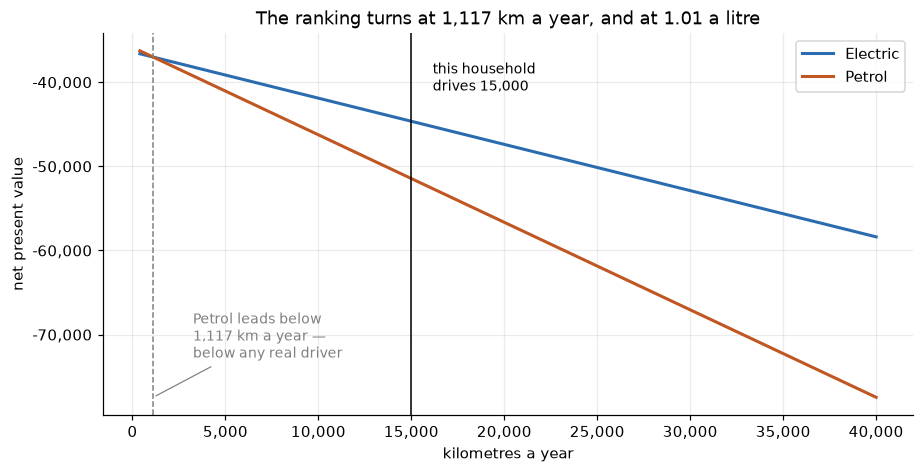

In [9]:
distance_switch = switch_point(
    marked, "annual km", better="Electric", worse="Petrol", bracket=(1_000.0, 60_000.0)
)
fuel_switch = switch_point(
    marked, "fuel price", better="Electric", worse="Petrol", bracket=(0.60, 4.00)
)
print(distance_switch)
print(fuel_switch)

driven = np.linspace(400.0, 40_000.0, 90)
sweep = one_way(marked, "annual km", driven)

fig, ax = plt.subplots()
sweep_chart(sweep, switch=distance_switch, ax=ax)

ax.annotate(
    f"{distance_switch.below} leads below\n{distance_switch.value:,.0f} km a year —\n"
    f"below any real driver",
    xy=(distance_switch.value, sweep.npv.min()),
    xytext=(26, 26),
    textcoords="offset points",
    fontsize=9,
    color="grey",
    arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.8},
)
ax.axvline(15_000.0, color="black", linewidth=1)
ax.annotate(
    "this household\ndrives 15,000",
    xy=(15_000.0, sweep.npv.max()),
    xytext=(14, -26),
    textcoords="offset points",
    fontsize=9,
)
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlabel("kilometres a year")
ax.set_title(
    f"The ranking turns at {distance_switch.value:,.0f} km a year, "
    f"and at {fuel_switch.value:.2f} a litre"
)
ax.legend(loc="upper right")
plt.show()

## The cliff in the means test

The purchase premium is read off a published income-by-dependants matrix, so
it does not taper — it steps. A household a hundred euros over a band
boundary loses the whole difference, and the bands are the only place in this
model where a small change in an input produces a discontinuous change in the
answer.

It does not change the decision here, though: the bottom panel never crosses.
Losing the entire grant costs this household about 3,500 in present value,
and the electric car was ahead by more than that.

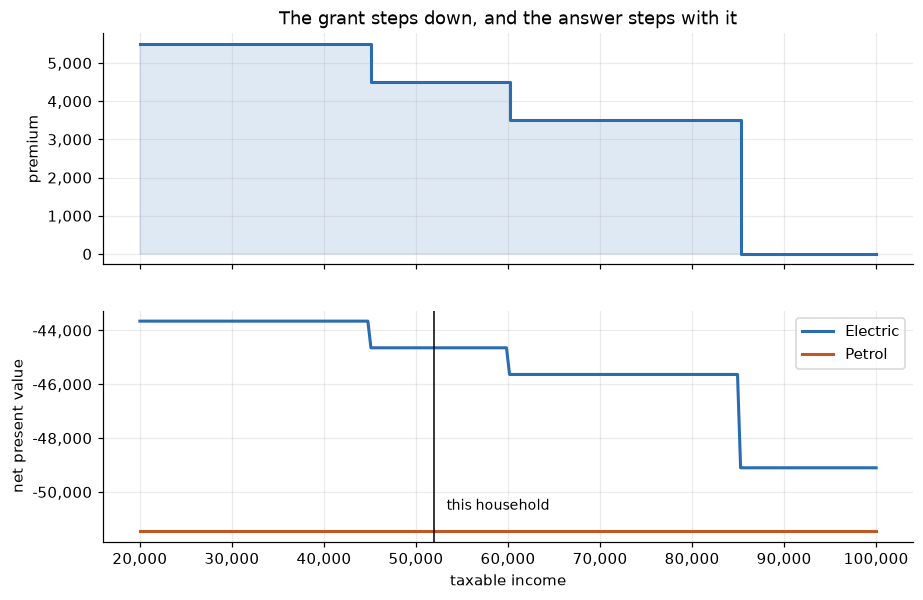

winner across the whole income range: {'Electric'}


In [10]:
incomes = np.linspace(20_000.0, 100_000.0, 240)
income_sweep = one_way(marked, "income", incomes)
grants = np.array([float(premium.grant(Household(value, 1))) for value in incomes])

fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True)

top.step(incomes, grants, where="post", color=ELECTRIC, linewidth=2)
top.fill_between(incomes, grants, step="post", color=ELECTRIC, alpha=0.15)
top.yaxis.set_major_formatter(MONEY)
top.set_ylabel("premium")
top.set_title("The grant steps down, and the answer steps with it")

bottom.plot(incomes, income_sweep.npv[0], color=ELECTRIC, linewidth=2, label="Electric")
bottom.plot(incomes, income_sweep.npv[1], color=PETROL, linewidth=2, label="Petrol")
bottom.axvline(52_000.0, color="black", linewidth=1)
bottom.annotate(
    "this household",
    xy=(52_000.0, income_sweep.npv.min()),
    xytext=(8, 14),
    textcoords="offset points",
    fontsize=9,
)
bottom.xaxis.set_major_formatter(MONEY)
bottom.yaxis.set_major_formatter(MONEY)
bottom.set_xlabel("taxable income")
bottom.set_ylabel("net present value")
bottom.legend(loc="upper right")
plt.show()

print("winner across the whole income range:", set(income_sweep.winners()))

## And with everything moving at once

Five parameters drawn together, twenty thousand times. Because no flow
source here rebuilds its structure from the draw, the whole simulation is one
vectorised pass rather than twenty thousand rebuilds of the tree.

resolved in one batched pass: True


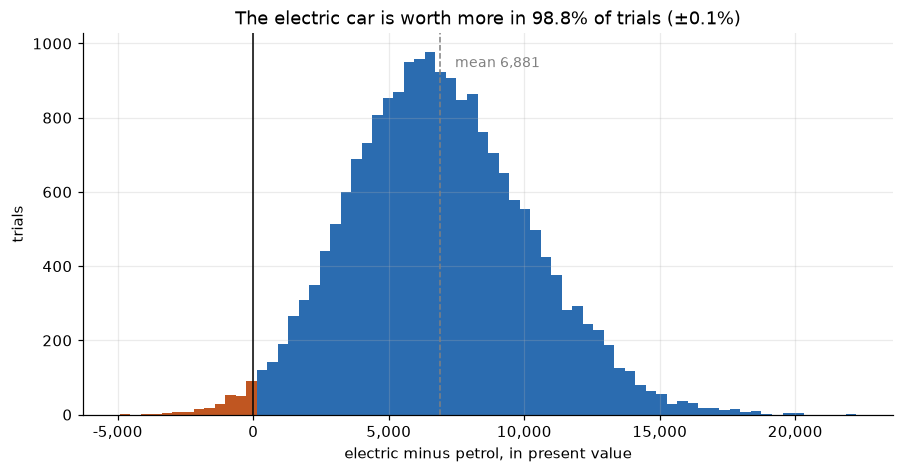

In [11]:
trials = simulate(marked, n=20_000, seed=20260930)
print(f"resolved in one batched pass: {trials.batched}")

difference = trials.values("Electric") - trials.values("Petrol")
share = trials.probability("Electric", "Petrol")

fig, ax = plt.subplots()
differential_chart(trials, "Electric", "Petrol", ax=ax)
ax.annotate(
    f"mean {difference.mean():,.0f}",
    xy=(difference.mean(), ax.get_ylim()[1]),
    xytext=(10, -22),
    textcoords="offset points",
    fontsize=9,
    color="grey",
)
ax.set_xlabel("electric minus petrol, in present value")
ax.set_title(
    f"The electric car is worth more in {share:.1%} of trials "
    f"(±{trials.standard_error('Electric', 'Petrol'):.1%})"
)
plt.show()

## What this example is really showing

The engine ranked two cash-flow streams. It never learned what a kilometre
is, what a kilowatt-hour costs, or that German households with children get a
larger grant. All of that lives in `simplyinvest.car`, behind the same
`Asset`, `UsageProfile` and `FlowSource` contracts any other domain
implements — which is the point of building the core without a domain in it.